In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [203]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score
from imblearn.over_sampling import SMOTE
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import pickle

In [6]:
df= pd.read_csv(r"C:\Users\dell\Downloads\WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [12]:
df.head(2)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No


In [14]:
df.shape

(7043, 21)

In [16]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [20]:
df.drop(['customerID'],axis=1,inplace=True)

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


#### unique values

In [41]:
num_cols= ['tenure','MonthlyCharges','TotalCharges']

for i in df.columns:
    if i not in num_cols:
        print(i,df[i].unique())
        print("----"*30)

gender ['Female' 'Male']
------------------------------------------------------------------------------------------------------------------------
SeniorCitizen [0 1]
------------------------------------------------------------------------------------------------------------------------
Partner ['Yes' 'No']
------------------------------------------------------------------------------------------------------------------------
Dependents ['No' 'Yes']
------------------------------------------------------------------------------------------------------------------------
PhoneService ['No' 'Yes']
------------------------------------------------------------------------------------------------------------------------
MultipleLines ['No phone service' 'No' 'Yes']
------------------------------------------------------------------------------------------------------------------------
InternetService ['DSL' 'Fiber optic' 'No']
---------------------------------------------------------------------

#### value_counts

In [43]:
for i in df.columns:
    if i not in num_cols:
        print(i,df[i].value_counts(dropna=False))
        print("----"*30)

gender gender
Male      3555
Female    3488
Name: count, dtype: int64
------------------------------------------------------------------------------------------------------------------------
SeniorCitizen SeniorCitizen
0    5901
1    1142
Name: count, dtype: int64
------------------------------------------------------------------------------------------------------------------------
Partner Partner
No     3641
Yes    3402
Name: count, dtype: int64
------------------------------------------------------------------------------------------------------------------------
Dependents Dependents
No     4933
Yes    2110
Name: count, dtype: int64
------------------------------------------------------------------------------------------------------------------------
PhoneService PhoneService
Yes    6361
No      682
Name: count, dtype: int64
------------------------------------------------------------------------------------------------------------------------
MultipleLines MultipleLines
No       

In [46]:
df['TotalCharges']= pd.to_numeric(df['TotalCharges'],errors='coerce')

In [48]:
df.dtypes

gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object

In [50]:
df.isna().sum()

gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [ ]:
# there are 11 missing values in the 'totalcharges'

### visualize the distribution of TotalCharges to check for outliers

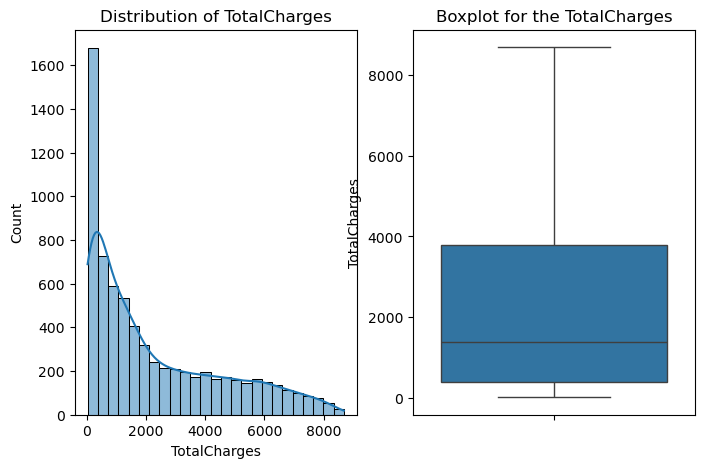

In [67]:
plt.figure(figsize=(8,5))
plt.subplot(1,2,1)
sns.histplot(df['TotalCharges'].dropna(),kde=True)
plt.title('Distribution of TotalCharges')

plt.subplot(1,2,2)
sns.boxplot(df['TotalCharges'].dropna())
plt.title('Boxplot for the TotalCharges')

plt.show()

In [ ]:
# since there are no outliers, we will fill missing values with mean 

In [69]:
df['TotalCharges']= df['TotalCharges'].fillna(df['TotalCharges'].mean())

In [73]:
df.isna().sum()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

#### target column

In [55]:
df['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

### Numerical Analysis

In [93]:
def plot_histogram(df,column_name):
    plt.figure(figsize=(5,3))
    sns.histplot(df[column_name], kde=True)
    plt.title(f"Distribution of {column_name}")

# calculation of mean and median

    col_mean= df[column_name].mean()
    col_median= df[column_name].median()

# add vertical lines for the mean and median

    plt.axvline(col_mean, color='Red', linestyle="--", label= 'Mean')
    plt.axvline(col_median, color='Green', linestyle="-", label='Median')

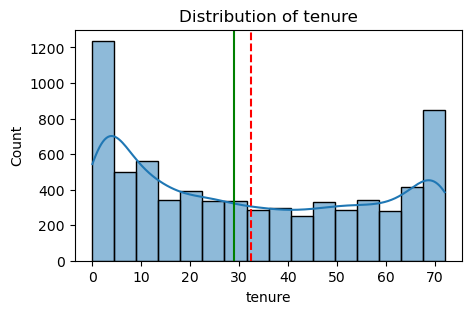

In [95]:
plot_histogram(df,'tenure')

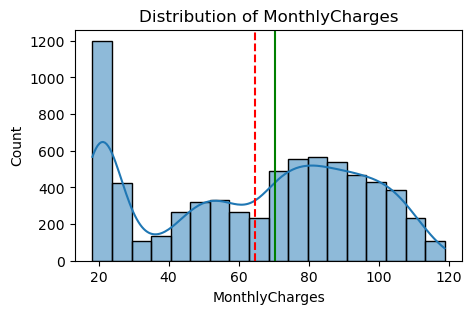

In [101]:
plot_histogram(df,'MonthlyCharges')

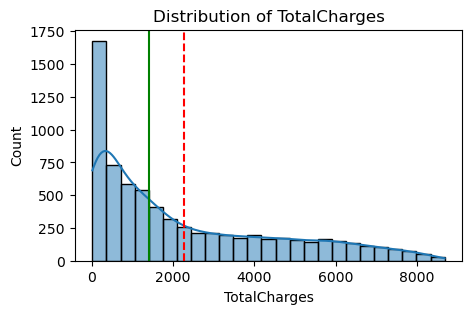

In [103]:
plot_histogram(df,'TotalCharges')

### boxplot for the numerical columns

In [120]:
def plt_boxplot(df,column_name):
    plt.figure(figsize=(5,3))
    sns.boxplot(df[column_name])
    plt.title(f"Boxplot of {column_name}")
    plt.ylabel(column_name)
    plt.show()

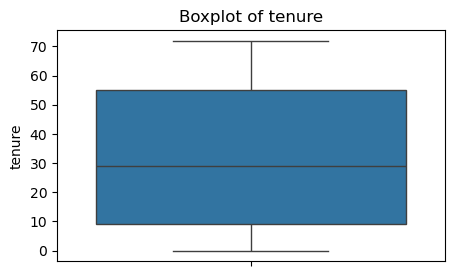

In [122]:
plt_boxplot(df,'tenure')

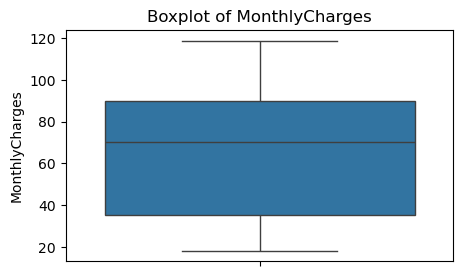

In [124]:
plt_boxplot(df,'MonthlyCharges')

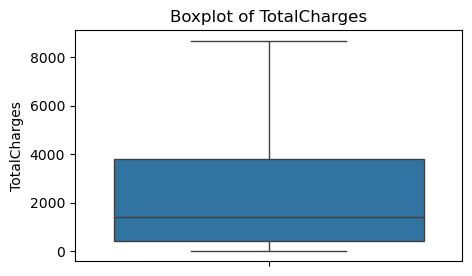

In [126]:
plt_boxplot(df,'TotalCharges')

### correlation of numerical 

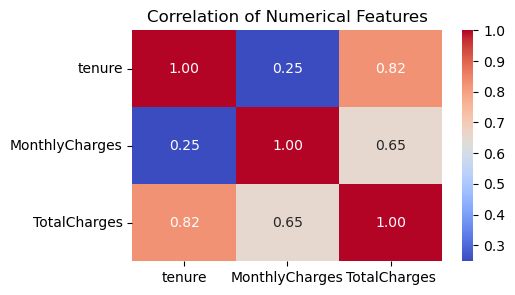

In [131]:
plt.figure(figsize=(5,3))
sns.heatmap(df[['tenure','MonthlyCharges','TotalCharges']].corr(),
            annot=True,cmap='coolwarm',fmt='.2f')
plt.title('Correlation of Numerical Features')
plt.show()

### Categorical Analysis

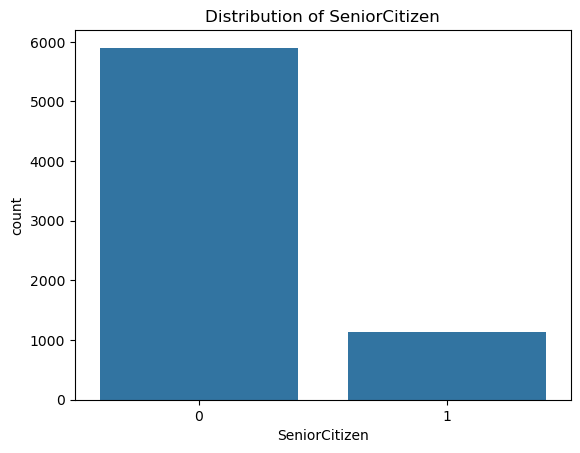

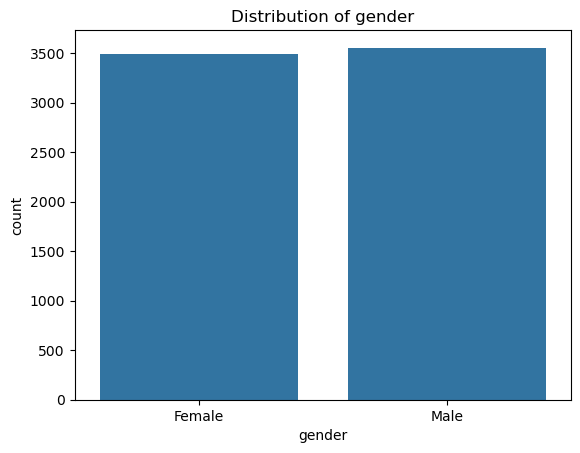

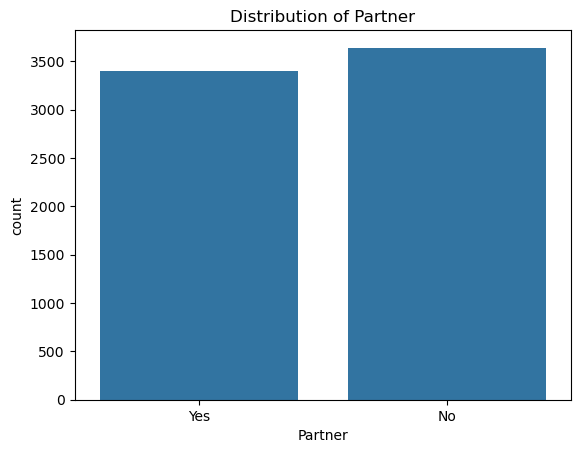

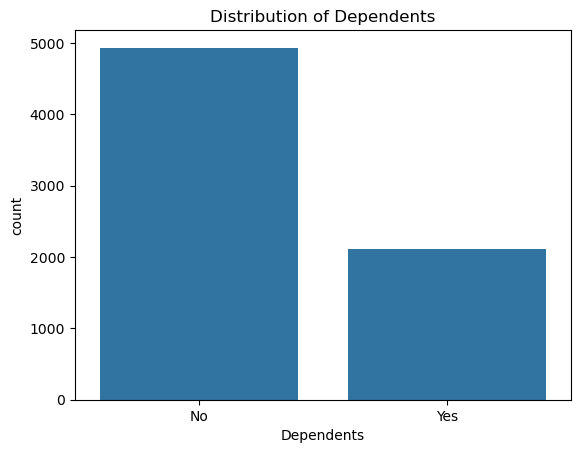

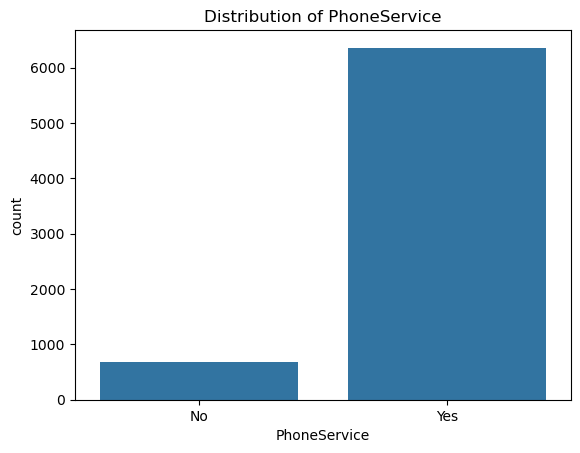

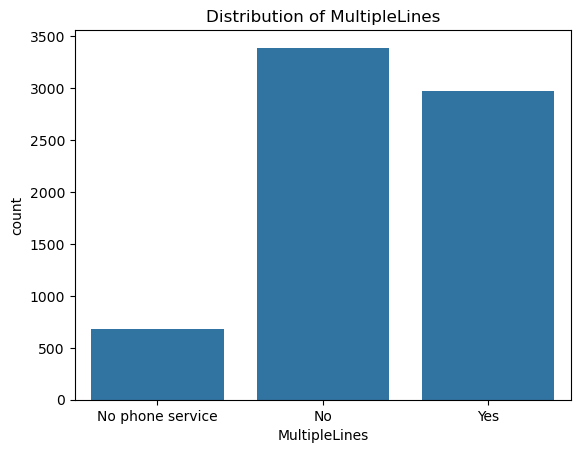

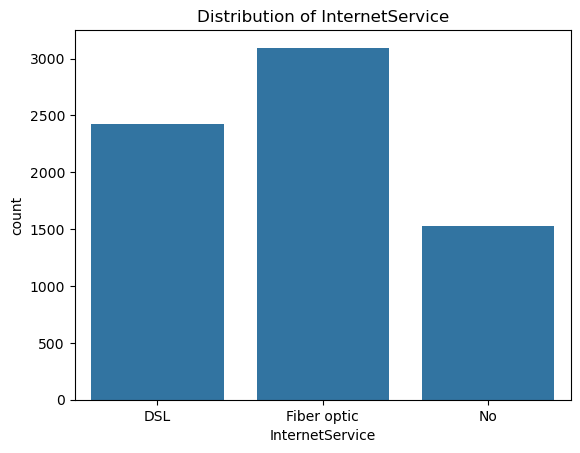

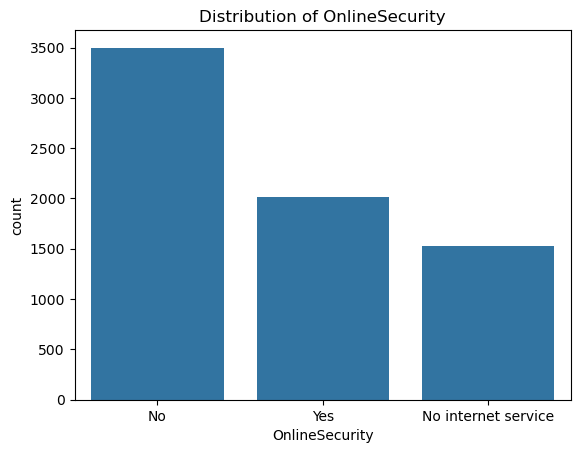

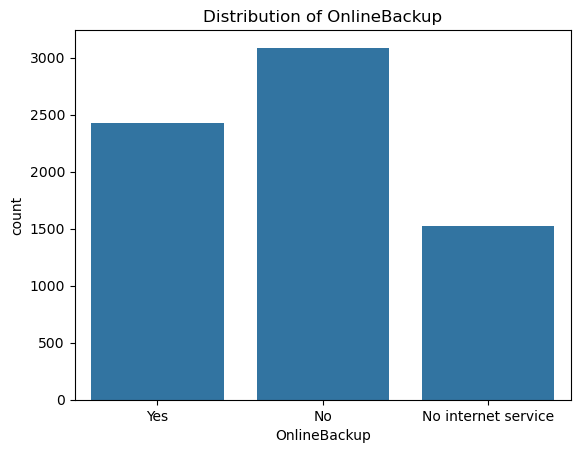

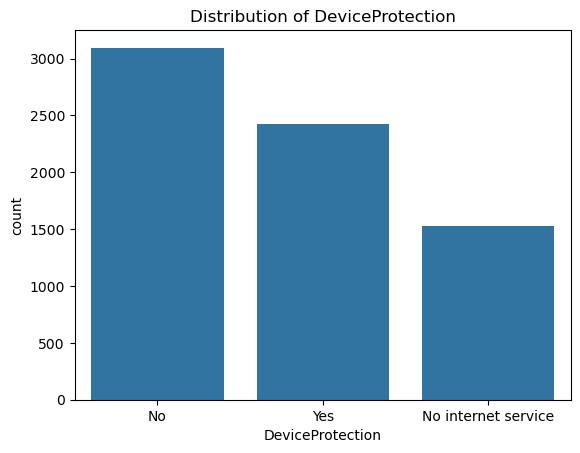

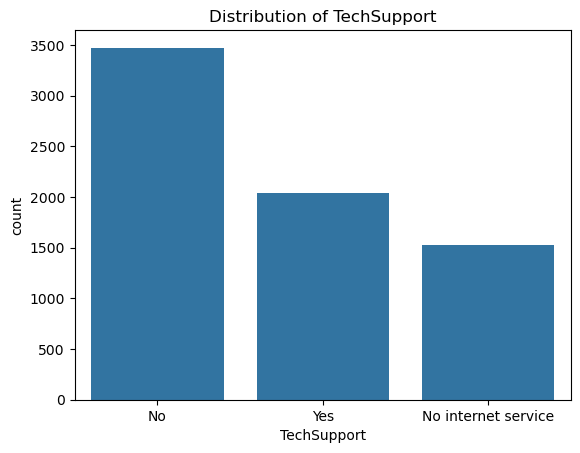

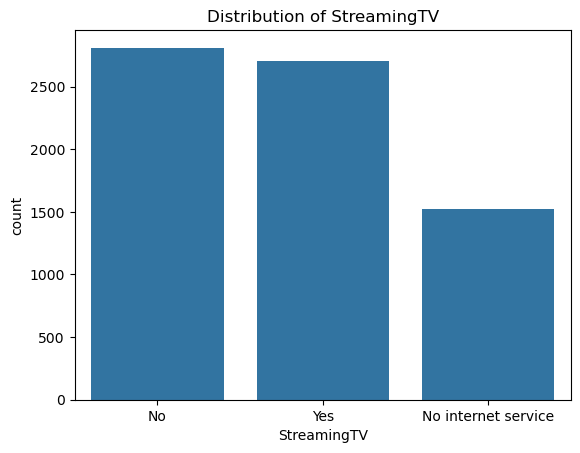

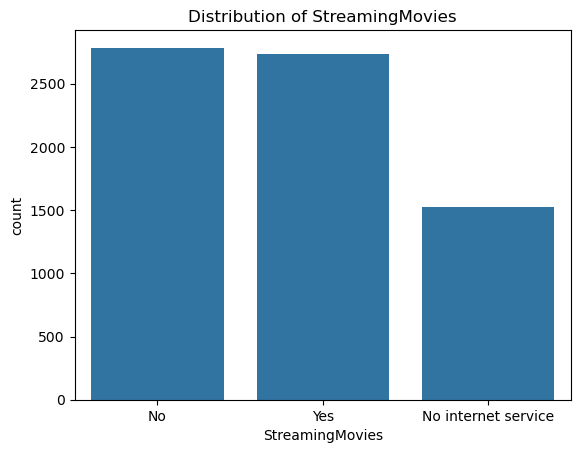

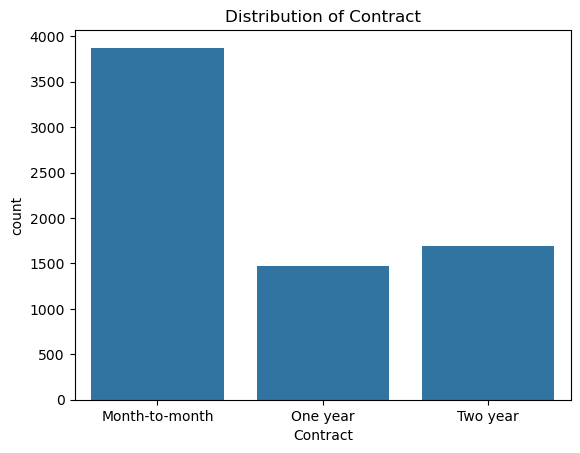

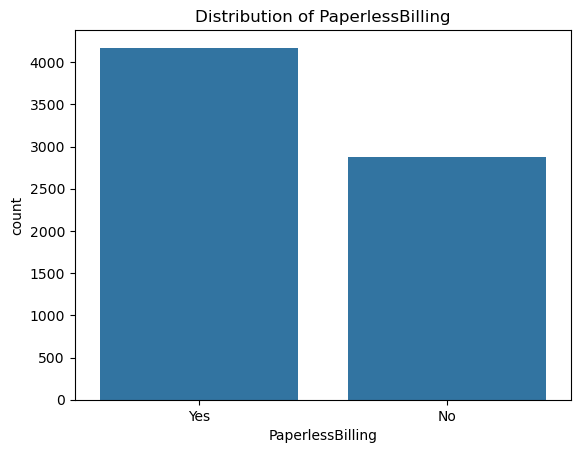

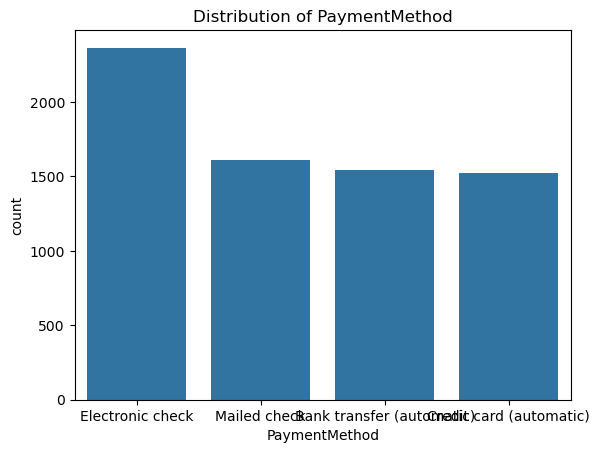

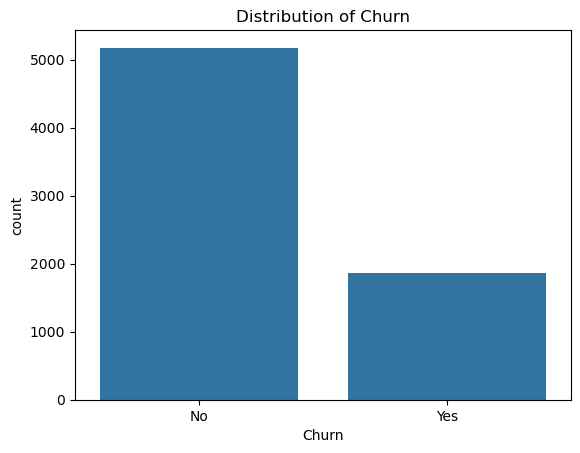

In [162]:
object_cols= df.select_dtypes(include=object).columns.to_list()
object_cols= ['SeniorCitizen']+ object_cols

for i in object_cols:
    sns.countplot(x=df[i])
    plt.title(f"Distribution of {i}")
    plt.show()

In [ ]:
## Insights

 1.dataset contains 7043 entries and 20 features
after dropping customerID
2.totalCharges was initially an object type and contained some missing values which then imputed with mean
3.significant no. of customers having very low tenure(new customer) and another peak at high tenure(loyal customer
4.most customers have lower total charges, while a smaller group has high charges indicating long-term high-spending customers
5. there are no  ooutliers in the dataset
6.strong +ve correlation b/w tenure and TotalCharges(0.83), suggest that customer who stays longer genrally accure total chages high 
and there is moderately +ve correlation b/w MonthlyCharges and TotalChages and lastly there is weak correlation b/w tenure 
and MonthlyCharges(0.25) which idicate that long-term customers dont necessarily have higher monthly charges compared to newer customers


### Data Pre-processing

In [169]:
for i in df.columns:
    print(df[i].value_counts())
    print("---"*30)

gender
Male      3555
Female    3488
Name: count, dtype: int64
------------------------------------------------------------------------------------------
SeniorCitizen
0    5901
1    1142
Name: count, dtype: int64
------------------------------------------------------------------------------------------
Partner
No     3641
Yes    3402
Name: count, dtype: int64
------------------------------------------------------------------------------------------
Dependents
No     4933
Yes    2110
Name: count, dtype: int64
------------------------------------------------------------------------------------------
tenure
1     613
72    362
2     238
3     200
4     176
     ... 
28     57
39     56
44     51
36     50
0      11
Name: count, Length: 73, dtype: int64
------------------------------------------------------------------------------------------
PhoneService
Yes    6361
No      682
Name: count, dtype: int64
-------------------------------------------------------------------------------------

In [171]:
df['Churn']= df['Churn'].map({'Yes':1,'No':0})

In [175]:
df.head(2)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0


### encoder

In [178]:
encoders={}

for col in object_cols:
    le=LabelEncoder()
    df[col]=le.fit_transform(df[col])
    encoders[col]=le

with open('encoders.pkl','wb') as f:
    pickle.dump(encoders,f)



In [180]:
encoders

{'SeniorCitizen': LabelEncoder(),
 'gender': LabelEncoder(),
 'Partner': LabelEncoder(),
 'Dependents': LabelEncoder(),
 'PhoneService': LabelEncoder(),
 'MultipleLines': LabelEncoder(),
 'InternetService': LabelEncoder(),
 'OnlineSecurity': LabelEncoder(),
 'OnlineBackup': LabelEncoder(),
 'DeviceProtection': LabelEncoder(),
 'TechSupport': LabelEncoder(),
 'StreamingTV': LabelEncoder(),
 'StreamingMovies': LabelEncoder(),
 'Contract': LabelEncoder(),
 'PaperlessBilling': LabelEncoder(),
 'PaymentMethod': LabelEncoder(),
 'Churn': LabelEncoder()}

### Train and Test split

In [183]:
x= df.drop('Churn',axis=1)
y= df['Churn']

In [185]:
x_train,x_test,y_train,y_test= train_test_split(x,y,test_size=0.2, random_state=42)

In [189]:
print(y_train.shape)
print(y_train.value_counts())

(5634,)
Churn
0    4138
1    1496
Name: count, dtype: int64


In [196]:
smote=SMOTE(random_state=42)
x_train_smote, y_train_smote= smote.fit_resample(x_train,y_train)

In [198]:
print(y_train_smote.shape)
print(y_train_smote.value_counts())

(8276,)
Churn
0    4138
1    4138
Name: count, dtype: int64


### Model Training

In [207]:
pip install xgboost


   ---------------------------------------- 0.0/72.0 MB ? eta -:--:--
   ---------------------------------------- 0.5/72.0 MB 5.6 MB/s eta 0:00:13
   -- ------------------------------------- 4.5/72.0 MB 15.8 MB/s eta 0:00:05
   ---- ----------------------------------- 8.9/72.0 MB 18.4 MB/s eta 0:00:04
   ------ --------------------------------- 11.3/72.0 MB 16.0 MB/s eta 0:00:04
   ------ --------------------------------- 12.1/72.0 MB 14.0 MB/s eta 0:00:05
   ------- -------------------------------- 12.8/72.0 MB 11.7 MB/s eta 0:00:06
   ------- -------------------------------- 13.6/72.0 MB 10.2 MB/s eta 0:00:06
   -------- ------------------------------- 15.7/72.0 MB 10.0 MB/s eta 0:00:06
   ----------- ---------------------------- 20.2/72.0 MB 11.4 MB/s eta 0:00:05
   ------------- -------------------------- 24.1/72.0 MB 12.1 MB/s eta 0:00:04
   --------------- ------------------------ 28.3/72.0 MB 12.8 MB/s eta 0:00:04
   ----------------- ---------------------- 31.7/72.0 MB 13.2 MB

In [214]:
from xgboost import XGBClassifier

models= {
    'decision_tree': DecisionTreeClassifier(random_state=42),
    'random_forest': RandomForestClassifier(random_state=42),
    'xgboost': XGBClassifier(random_state=42)
}

In [228]:
from sklearn.model_selection import cross_val_score

cv_scores = {}

# perform 5-fold cross-validation for each model
for model_name, model in models.items():
    print(f"Training {model_name} with default parameters")

    scores = cross_val_score(
        model,
        x_train_smote,
        y_train_smote,
        cv=5
    )

    cv_scores[model_name] = scores

    print(f"{model_name} cross-validation scores: {scores}")
    print(f"{model_name} cross-validation mean score: {scores.mean()}")
    print("---" * 20)


Training decision_tree with default parameters
decision_tree cross-validation scores: [0.69202899 0.70694864 0.82537764 0.8429003  0.84350453]
decision_tree cross-validation mean score: 0.7821520206664039
------------------------------------------------------------
Training random_forest with default parameters
random_forest cross-validation scores: [0.72826087 0.77220544 0.90151057 0.89909366 0.89667674]
random_forest cross-validation mean score: 0.8395494548798108
------------------------------------------------------------
Training xgboost with default parameters
xgboost cross-validation scores: [0.71799517 0.7510574  0.90332326 0.89063444 0.90090634]
xgboost cross-validation mean score: 0.8327833238466364
------------------------------------------------------------


In [232]:
rfc= RandomForestClassifier(random_state=42)
rfc.fit(x_train_smote,y_train_smote)

RandomForestClassifier(random_state=42)

In [234]:
y_test_predict=rfc.predict(x_test)

print("Accuracy_score:\n", accuracy_score(y_test,y_test_predict))
print("confusion_matrix:\n", confusion_matrix(y_test,y_test_predict))
print("classification_report:\n", classification_report(y_test,y_test_predict))

Accuracy_score:
 0.7714691270404542
confusion_matrix:
 [[873 163]
 [159 214]]
classification_report:
               precision    recall  f1-score   support

           0       0.85      0.84      0.84      1036
           1       0.57      0.57      0.57       373

    accuracy                           0.77      1409
   macro avg       0.71      0.71      0.71      1409
weighted avg       0.77      0.77      0.77      1409

